 #  Insurance Penetration and Growth Potential Analysis

### Scenario

PhonePe has entered the insurance segment and provides users
with different insurance services.

The objective is to analyze insurance transactions across
states and time periods, identify high-performing regions,
and understand growth opportunities.

####  Objective

- Identify states with the highest insurance transactions.
- Analyze insurance amount across states.
- Understand year-wise insurance growth.
- Identify regions with potential for insurance expansion.

In [1]:
import os
import json
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import pyodbc
import numpy as np

In [2]:
conn = pyodbc.connect(
    "DRIVER={ODBC Driver 18 for SQL Server};"
    "SERVER=DESKTOP-55JNORK\\SQLEXPRESS;"
    "DATABASE=phonepe;"
    "Trusted_Connection=yes;"
    "TrustServerCertificate=yes;"
)

cursor = conn.cursor()

print("OK")



OK


## Load Insurance Data

In [3]:
query3 = """
select top 10 *
from aggregated_insurance
"""

df3= pd.read_sql(query3, conn)
df3

C:\Users\Devendra\AppData\Local\Temp\ipykernel_24592\1544807277.py:6: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df3= pd.read_sql(query3, conn)


,States,Years,Quarter,Insurance_type,Insurance_count,Insurance_amount
0,Andaman & Nicobar,2020,2,Insurance,6,1360
1,Andaman & Nicobar,2020,3,Insurance,41,15380
2,Andaman & Nicobar,2020,4,Insurance,124,157975
3,Andaman & Nicobar,2021,1,Insurance,225,244266
4,Andaman & Nicobar,2021,2,Insurance,137,181504
5,Andaman & Nicobar,2021,3,Insurance,230,305235
6,Andaman & Nicobar,2021,4,Insurance,757,1056380
7,Andaman & Nicobar,2022,1,Insurance,768,1131287
8,Andaman & Nicobar,2022,2,Insurance,501,779740
9,Andaman & Nicobar,2022,3,Insurance,643,902466


### Top 10 States by Insurance Transactions

In [6]:
df3.columns

Index(['States', 'Years', 'Quarter', 'Insurance_type', 'Insurance_count',
       'Insurance_amount'],
      dtype='str')

C:\Users\Devendra\AppData\Local\Temp\ipykernel_24592\3314980309.py:10: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_ins = pd.read_sql(insurance_query, conn)


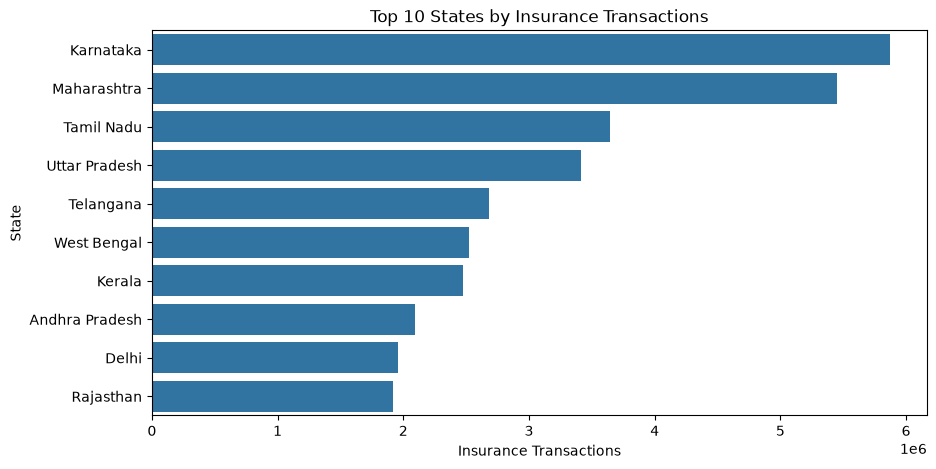

In [7]:
insurance_query = """
SELECT TOP 10
    States,
    SUM(Insurance_count) AS Total_Insurance_Transactions
FROM aggregated_insurance
GROUP BY States
ORDER BY SUM(Insurance_count) DESC
"""

df_ins = pd.read_sql(insurance_query, conn)

plt.figure(figsize=(10,5))

sns.barplot(
    data=df_ins,
    x="Total_Insurance_Transactions",
    y="States"
)

plt.title("Top 10 States by Insurance Transactions")
plt.xlabel("Insurance Transactions")
plt.ylabel("State")

plt.show()

### which states have the highest insurance adoption

## Insurance Amount by State

C:\Users\Devendra\AppData\Local\Temp\ipykernel_24592\2817561220.py:10: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_amount = pd.read_sql(query, conn)


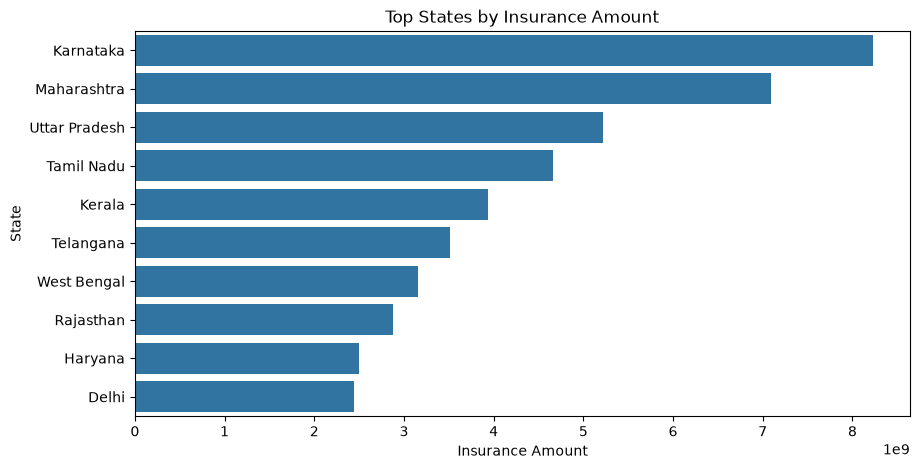

In [9]:
query = """
SELECT TOP 10
    States,
    SUM(Insurance_amount) AS Total_Amount
FROM aggregated_insurance
GROUP BY States
ORDER BY SUM(Insurance_amount) DESC
"""

df_amount = pd.read_sql(query, conn)

plt.figure(figsize=(10,5))

sns.barplot(
    data=df_amount,
    x="Total_Amount",
    y="States"
)

plt.title("Top States by Insurance Amount")
plt.xlabel("Insurance Amount")
plt.ylabel("State")

plt.show()

#### which states generate the highest insurance transaction value

## Insurance Growth by Year 

C:\Users\Devendra\AppData\Local\Temp\ipykernel_24592\2645304619.py:10: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_pie = pd.read_sql(query, conn)


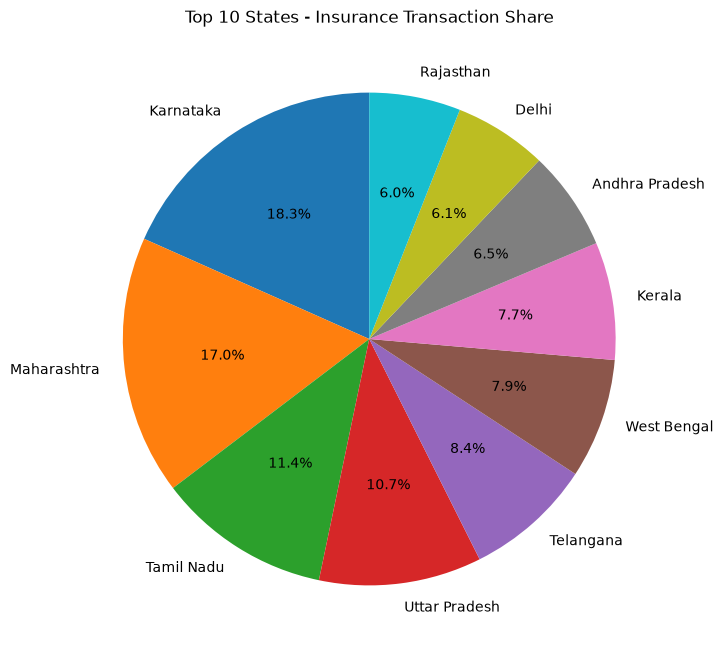

In [10]:
query = """
SELECT TOP 10
    States,
    SUM(Insurance_count) AS Total_Transactions
FROM aggregated_insurance
GROUP BY States
ORDER BY SUM(Insurance_count) DESC
"""

df_pie = pd.read_sql(query, conn)

plt.figure(figsize=(8,8))

plt.pie(
    df_pie["Total_Transactions"],
    labels=df_pie["States"],
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Top 10 States - Insurance Transaction Share")

plt.show()

#### how insurance transactions are growing over time

#### Recommendations
1. Focus marketing campaigns on states with high insurance transactions to increase policy adoption further.
2. Target low-penetration states with awareness campaigns, attractive offers, and affordable insurance products.
3. Partner with insurers based on state-wise demand to provide suitable insurance products to customers.

### Conclusion

PhonePe's insurance segment has strong growth potential. Focusing on high-adoption states and expanding into low-adoption regions can increase insurance penetration and customer growth